In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
# clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache_cp = pickle.load(f)

In [5]:
# use for dso server

# gmm_cache = dict()
# for key, value in gmm_cache_cp.items():
#     new_key = key.replace("/mnt/d/Users/Admin/Projects/dso/SAR_ML", workspace)
#     gmm_cache[new_key] = value

gmm_cache = gmm_cache_cp

In [6]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [7]:
def _get_features_from_model(model, dataset, device):
    """
    parameters:
    model: PyTorch model to extract features from
    dataset: PyTorch Dataset to extract features for
    device: torch.device to perform computations on

    returns:
    features: numpy array of shape (num_samples, feature_dim) containing extracted features
    labels: numpy array of shape (num_samples,) containing corresponding labels
    """
    model = model.to(device)
    model.eval()

    feature_extractor = nn.Sequential(*list(model.children())[:-1])
    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    features, labels_list = [], []

    with torch.no_grad():
        for inputs, targets in DataLoader(
            dataset, batch_size = 32, 
            shuffle = False, num_workers = 8,
            pin_memory = True, persistent_workers=True, 
            worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)
            ):

            inputs = inputs.to(device)
            feats = feature_extractor(inputs)
            feats = feats.view(feats.size(0), -1)
            features.append(feats.cpu())
            labels_list.append(targets)

    features = torch.cat(features).numpy()
    labels = torch.cat(labels_list).numpy()

    return features, labels

In [8]:
def _gaussian_fit(features, labels, dataset):
    """
    Fit a Gaussian distribution to the features of a specific class.

    parameters:
    features: cupy array of shape (num_samples, feature_dim) containing extracted features
    labels: cupy array of shape (num_samples,) containing corresponding labels
    dataset: PyTorch Dataset containing the class information

    returns:
    class_mu: numpy array of shape (feature_dim,) containing the mean vector of the fitted Gaussian
    sigma_inv: numpy array of shape (feature_dim, feature_dim) containing the inverse covariance matrix of the fitted Gaussian
    """

    class_paras = {}
    for class_idx in dataset.class_to_idx.values():
        targets = (labels == class_idx)
        class_features = features[targets]

        class_mu = class_features.mean(axis = 0)
        class_paras[class_idx] = class_mu

    sigma = np.cov(features, rowvar = False) # rowvar means observations are rows, features are columns
    sigma_inv = np.linalg.inv(sigma)

    return class_paras, sigma_inv

In [9]:
def _mahalanobis_distance(feature, class_paras, sigma_inv):
    """
    Compute the Mahalanobis distance between a feature vector (usually test samples) and a class mean.

    parameters:
    feature: numpy array of shape (feature_dim,) containing the feature vector
    class_paras: dictionary mapping class indices to their mean vectors
    sigma_inv: numpy array of shape (feature_dim, feature_dim) containing the inverse covariance matrix

    returns:
    distance: vector representing the Mahalanobis distance from class distributions (shape of (num_classes,))
    """
    dist_vector = np.zeros(len(class_paras))
    for class_idx, class_mu in class_paras.items():
        diff = feature - class_mu
        dist_vector[class_idx] = np.sqrt(diff.T @ sigma_inv @ diff)
    return dist_vector

In [10]:
def _mahalanobis_distance_for_dataset(features, class_paras, sigma_inv):
    """
    Compute the Mahalanobis distance for a set of features against class distributions.

    parameters:
    features: numpy array of shape (num_samples, feature_dim) containing feature vectors
    class_paras: dictionary mapping class indices to their mean vectors
    sigma_inv: numpy array of shape (feature_dim, feature_dim) containing the inverse covariance matrix

    returns:
    distances: numpy array of shape (num_samples, num_classes) containing Mahalanobis distances to each class
    """
    num_samples = features.shape[0]
    num_classes = len(class_paras)
    distances = np.zeros((num_samples, num_classes))

    for i in range(num_samples):
        distances[i, :] = _mahalanobis_distance(features[i], class_paras, sigma_inv)

    return distances

In [37]:
for x in range(2):
    test_acc_lst = []
    device = torch.cuda.set_device("cuda:0")
    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    for i, seed in enumerate(seed_lst):
        set_seed(seed)
        model = models.resnet18(weights = None) # dont load ImageNet Weights
        # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
        model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
        )
        # Load your trained weights
        model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
            map_location=device
        ))

        # this gives the synth_features and synth_labels
        SSR_synth_features, SSR_synth_labels = _get_features_from_model(model, SSR_synth_ds, device)
        SSR_synth_class_paras, SSR_synth_sigma_inv = _gaussian_fit(SSR_synth_features, SSR_synth_labels, SSR_synth_ds)

        meas_features, meas_labels = _get_features_from_model(model, meas_ds, device)
        meas_distances = _mahalanobis_distance_for_dataset(meas_features, SSR_synth_class_paras, SSR_synth_sigma_inv)

        pred_class = np.argmin(meas_distances, axis = 1)
        test_acc = (pred_class == meas_labels).sum() / len(meas_labels)
        print(f"Seed: {seed}, Test Accuracy: {test_acc:.4f}")
        test_acc_lst.append(test_acc)

Seed: 10, Test Accuracy: 0.8981
Seed: 42, Test Accuracy: 0.9219
Seed: 100, Test Accuracy: 0.8952
Seed: 123, Test Accuracy: 0.9063
Seed: 666, Test Accuracy: 0.8840
Seed: 777, Test Accuracy: 0.9026
Seed: 849, Test Accuracy: 0.9175
Seed: 1000, Test Accuracy: 0.9048
Seed: 1111, Test Accuracy: 0.8996
Seed: 1234, Test Accuracy: 0.9175
Seed: 10, Test Accuracy: 0.8981
Seed: 42, Test Accuracy: 0.9219
Seed: 100, Test Accuracy: 0.8952
Seed: 123, Test Accuracy: 0.9063
Seed: 666, Test Accuracy: 0.8840
Seed: 777, Test Accuracy: 0.9026
Seed: 849, Test Accuracy: 0.9175
Seed: 1000, Test Accuracy: 0.9048
Seed: 1111, Test Accuracy: 0.8996
Seed: 1234, Test Accuracy: 0.9175


In [7]:
SSR_test_acc_lst = []
device = torch.cuda.set_device("cuda:0")
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    SSR_synth_features, SSR_synth_labels = _get_features_from_model(model, SSR_synth_ds, device, seed)
    SSR_synth_class_paras, SSR_synth_sigma_inv = _gaussian_fit(SSR_synth_features, SSR_synth_labels, SSR_synth_ds)

    meas_features, meas_labels = _get_features_from_model(model, meas_ds, device, seed)
    SSR_meas_distances = _mahalanobis_distance_for_dataset(meas_features, SSR_synth_class_paras, SSR_synth_sigma_inv)

    pred_class = np.argmin(SSR_meas_distances, axis = 1)
    test_acc = (pred_class == meas_labels).sum() / len(meas_labels)
    print(f"Seed: {seed}, Test Accuracy: {test_acc:.4f}")
    SSR_test_acc_lst.append(test_acc)

Seed: 10, Test Accuracy: 0.8981
Seed: 42, Test Accuracy: 0.9219
Seed: 100, Test Accuracy: 0.8952
Seed: 123, Test Accuracy: 0.9063
Seed: 666, Test Accuracy: 0.8840
Seed: 777, Test Accuracy: 0.9026
Seed: 849, Test Accuracy: 0.9175
Seed: 1000, Test Accuracy: 0.9048
Seed: 1111, Test Accuracy: 0.8996
Seed: 1234, Test Accuracy: 0.9175


In [8]:
SSR_test_acc_arr = np.array(SSR_test_acc_lst)
print(f"Min: {SSR_test_acc_arr.min() * 100:.4f}")
print(f"Max: {SSR_test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {SSR_test_acc_arr.mean() * 100:.4f}, {SSR_test_acc_arr.std() * 100:.4f}")

Min: 88.4015
Max: 92.1933
Avg, Std: 90.4758, 1.1035


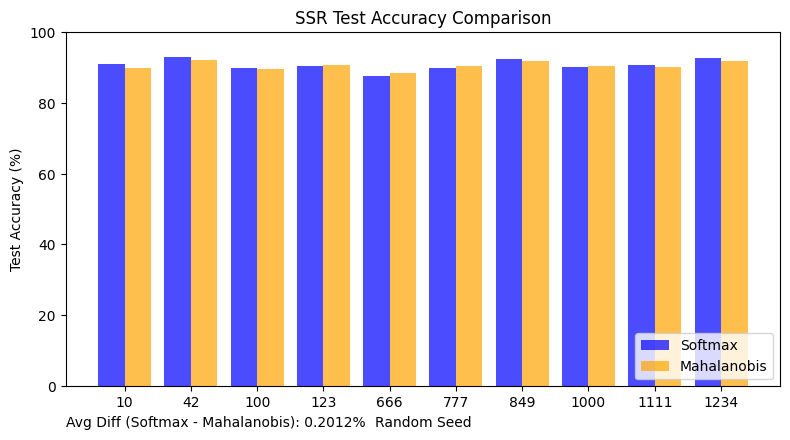

In [9]:
fig = plt.figure(figsize=(8, 4.5))
ax = fig.add_subplot(111)

SSR_softmax = np.array([0.9086, 0.9279, 0.8967, 0.9026, 0.8751, 0.8981, 0.9234, 0.9011, 0.9078, 0.9264])
SSR_mahalanobis = np.array(SSR_test_acc_lst)

w, x = 0.4, np.arange(len(seed_lst))
ax.bar(x - w/2, SSR_softmax * 100, width = w, label = "Softmax", color = "blue", alpha = 0.7)
ax.bar(x + w/2, SSR_mahalanobis * 100, width = w, label = "Mahalanobis", color = "orange", alpha = 0.7)
ax.set_xticks(x)
ax.set_xticklabels([str(seed) for seed in seed_lst])
ax.text(0, -0.115, 
        f"Avg Diff (Softmax - Mahalanobis): {(SSR_softmax.mean() - SSR_mahalanobis.mean()) * 100:.4f}%",
        transform=ax.transAxes)
ax.set_xlabel("Random Seed")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("SSR Test Accuracy Comparison")
ax.set_ylim(0, 100)
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

In [ ]:
for x in range(2):
    test_acc_lst = []
    device = torch.device("cuda")
    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    for i, seed in enumerate(seed_lst):
        model = models.resnet18(weights = None) # dont load ImageNet Weights
        # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
        model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
        )
        # Load your trained weights
        model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug_exp1_full_runs/rn18_seed{seed}_b16.pth"),
            map_location=device
        ))

        # this gives the synth_features and synth_labels
        synth_features, synth_labels = _get_features_from_model(model, synth_ds, device)
        synth_class_paras, synth_sigma_inv = _gaussian_fit(synth_features, synth_labels, synth_ds)

        meas_features, meas_labels = _get_features_from_model(model, meas_ds, device)
        wo_aug_meas_distances = _mahalanobis_distance_for_dataset(meas_features, synth_class_paras, synth_sigma_inv)

        pred_class = np.argmin(wo_aug_meas_distances, axis = 1)
        test_acc = (pred_class == meas_labels).sum() / len(meas_labels)
        print(f"Seed: {seed}, Test Accuracy: {test_acc:.4f}")
        test_acc_lst.append(test_acc)

Seed: 10, Test Accuracy: 0.8439
Seed: 42, Test Accuracy: 0.8468
Seed: 100, Test Accuracy: 0.8431
Seed: 123, Test Accuracy: 0.8558
Seed: 666, Test Accuracy: 0.8297
Seed: 777, Test Accuracy: 0.8669
Seed: 849, Test Accuracy: 0.8506
Seed: 1000, Test Accuracy: 0.8595
Seed: 1111, Test Accuracy: 0.8476
Seed: 1234, Test Accuracy: 0.8706
Seed: 10, Test Accuracy: 0.8439
Seed: 42, Test Accuracy: 0.8468
Seed: 100, Test Accuracy: 0.8431
Seed: 123, Test Accuracy: 0.8558
Seed: 666, Test Accuracy: 0.8297
Seed: 777, Test Accuracy: 0.8669
Seed: 849, Test Accuracy: 0.8506
Seed: 1000, Test Accuracy: 0.8595
Seed: 1111, Test Accuracy: 0.8476
Seed: 1234, Test Accuracy: 0.8706


In [10]:
wo_aug_test_acc_lst = []
device = torch.device("cuda")
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
for i, seed in enumerate(seed_lst):
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels = _get_features_from_model(model, synth_ds, device, seed)
    synth_class_paras, synth_sigma_inv = _gaussian_fit(synth_features, synth_labels, synth_ds)

    meas_features, meas_labels = _get_features_from_model(model, meas_ds, device, seed)
    meas_distances = _mahalanobis_distance_for_dataset(meas_features, synth_class_paras, synth_sigma_inv)

    pred_class = np.argmin(meas_distances, axis = 1)
    test_acc = (pred_class == meas_labels).sum() / len(meas_labels)
    print(f"Seed: {seed}, Test Accuracy: {test_acc:.4f}")
    wo_aug_test_acc_lst.append(test_acc)

Seed: 10, Test Accuracy: 0.8439
Seed: 42, Test Accuracy: 0.8468
Seed: 100, Test Accuracy: 0.8431
Seed: 123, Test Accuracy: 0.8558
Seed: 666, Test Accuracy: 0.8297
Seed: 777, Test Accuracy: 0.8669
Seed: 849, Test Accuracy: 0.8506
Seed: 1000, Test Accuracy: 0.8595
Seed: 1111, Test Accuracy: 0.8476
Seed: 1234, Test Accuracy: 0.8706


In [11]:
wo_aug_test_acc_arr = np.array(wo_aug_test_acc_lst)
print(f"Min: {wo_aug_test_acc_arr.min() * 100:.4f}")
print(f"Max: {wo_aug_test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {wo_aug_test_acc_arr.mean() * 100:.4f}, {wo_aug_test_acc_arr.std() * 100:.4f}")

Min: 82.9740
Max: 87.0632
Avg, Std: 85.1450, 1.1512


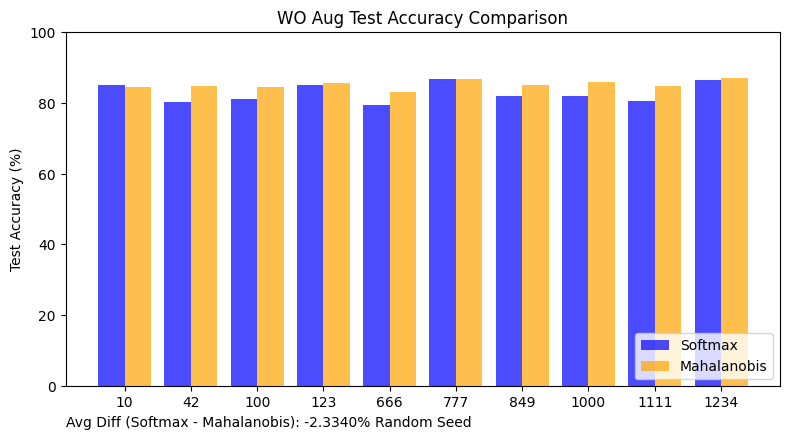

In [12]:
fig = plt.figure(figsize=(8, 4.5))
ax = fig.add_subplot(111)

wo_aug_softmax = np.array([0.8513, 0.8007, 0.8112, 0.8491, 0.7941, 0.8669, 0.8186, 0.8186, 0.8059, 0.8647])
wo_aug_mahalanobis = np.array(wo_aug_test_acc_lst)

w, x = 0.4, np.arange(len(seed_lst))
ax.bar(x - w/2, wo_aug_softmax * 100, width = w, label = "Softmax", color = "blue", alpha = 0.7)
ax.bar(x + w/2, wo_aug_mahalanobis * 100, width = w, label = "Mahalanobis", color = "orange", alpha = 0.7)
ax.set_xticks(x)
ax.set_xticklabels([str(seed) for seed in seed_lst])
ax.text(0, -0.115, 
        f"Avg Diff (Softmax - Mahalanobis): {(wo_aug_softmax.mean() - wo_aug_mahalanobis.mean()) * 100:.4f}%",
        transform=ax.transAxes)
ax.set_xlabel("Random Seed")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("WO Aug Test Accuracy Comparison")
ax.set_ylim(0, 100)
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

In [66]:
wo_aug_test_acc_lst = []
device = torch.device("cuda")
seed_lst = [1234]
for i, seed in enumerate(seed_lst):
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(synth_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/wo_aug_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    synth_features, synth_labels = _get_features_from_model(model, synth_ds, device, seed)
    synth_class_paras, synth_sigma_inv = _gaussian_fit(synth_features, synth_labels, synth_ds)

    meas_features, meas_labels = _get_features_from_model(model, meas_ds, device, seed)
    meas_distances = _mahalanobis_distance_for_dataset(meas_features, synth_class_paras, synth_sigma_inv)

    pred_class = np.argmin(meas_distances, axis = 1)
    test_acc = (pred_class == meas_labels).sum() / len(meas_labels)
    print(f"Seed: {seed}, Test Accuracy: {test_acc:.4f}")
    wo_aug_test_acc_lst.append(test_acc)

Seed: 1234, Test Accuracy: 0.8706


In [ ]:
def _k_nearest_neighbors(test_sample, train_features, sigma_inv, k=5):
    """
    Compute the k-nearest neighbors for a test sample given training features, sigma_inv.

    """
    vec_diff = test_sample - train_features
    distance = np.sqrt(np.sum(vec_diff @ sigma_inv * vec_diff, axis=1))
    knn_indices = np.argsort(distance)[:k]

    return knn_indices, distance[knn_indices]

In [68]:
knn_idx_5, knn_dist_5 =_k_nearest_neighbors(meas_features[0, :], synth_features, synth_sigma_inv, k=5)
knn_idx_5, knn_dist_5

(array([ 122,   49,  163,  679, 1302]),
 array([70.36643   , 70.86079093, 71.04188711, 71.14842927, 71.17228586]))

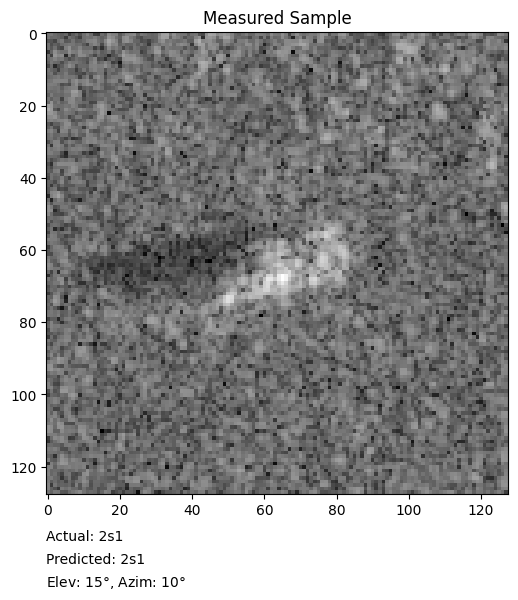

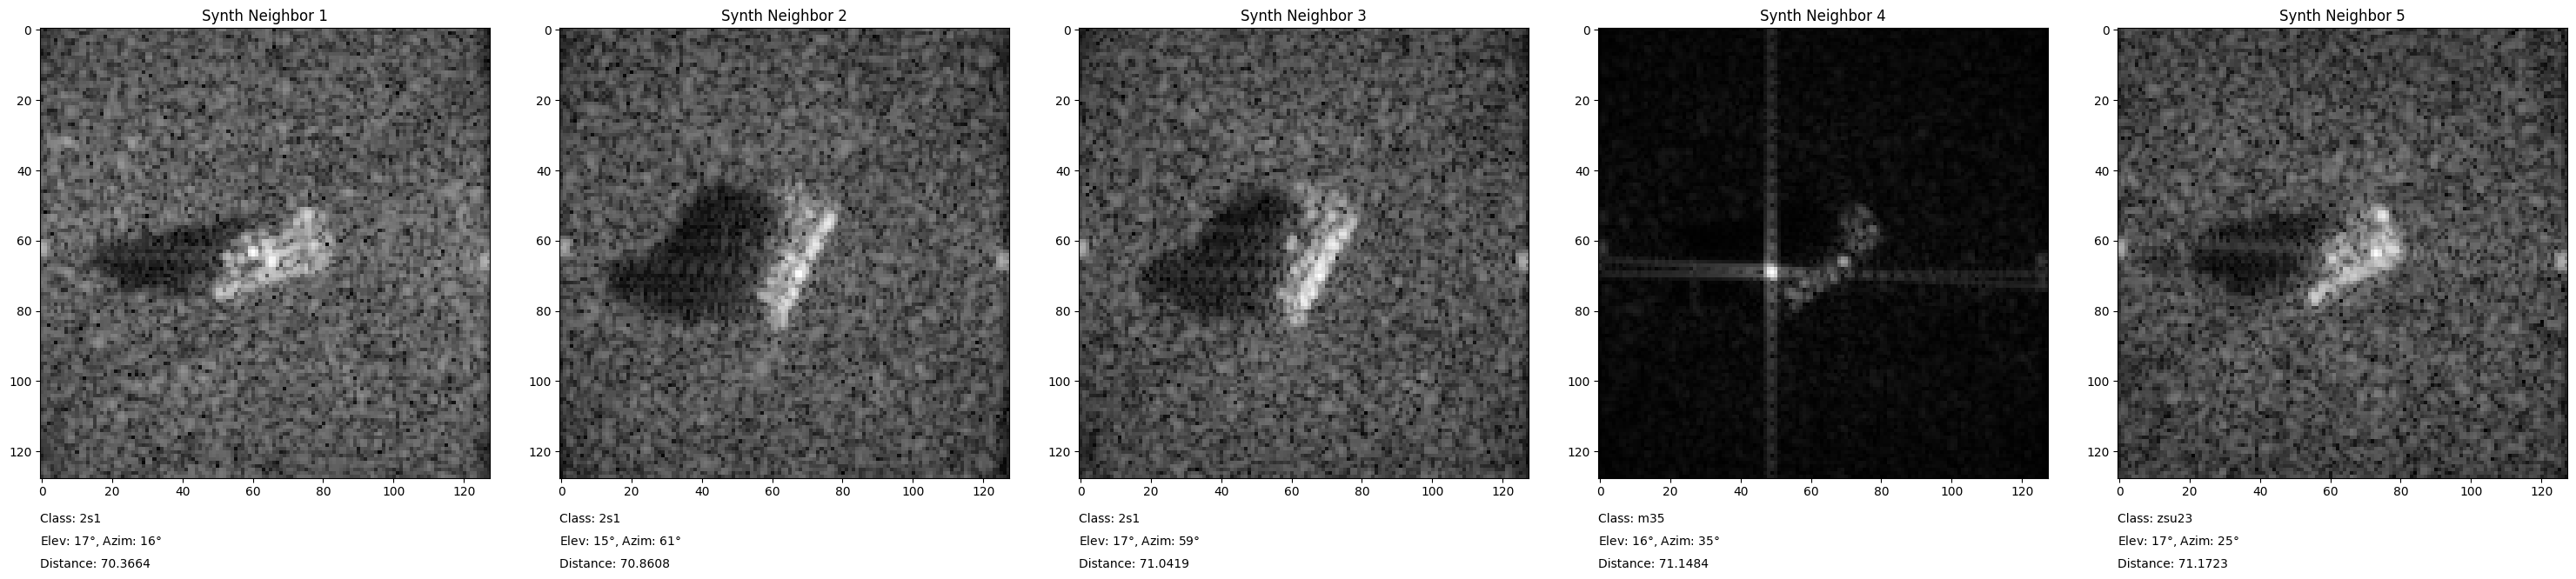

In [90]:
# measured sample visualization
meas_idx = 0
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(meas_ds[meas_idx][0][0], cmap = "gray")

meas_sample_path, meas_sample_class = meas_ds.samples[meas_idx]
elev_re = re.search(r'elevDeg_(\d+)', meas_sample_path)
azim_re = re.search(r'azCenter_(\d+)', meas_sample_path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

ax.set_title(f"Measured Sample")
ax.text(0, -0.1, f"Actual: {meas_ds.classes[meas_sample_class]}", transform=ax.transAxes)
ax.text(0, -0.15, f"Predicted: {meas_ds.classes[pred_class[meas_idx]]}", transform=ax.transAxes)
ax.text(0, -0.2, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
plt.show()

fig = plt.figure(figsize=(30, 6))
for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1)
    synth_idx = knn_idx_5[i]
    ax.imshow(synth_ds[synth_idx][0][0], cmap = "gray")
    synth_sample_path, synth_sample_class = synth_ds.samples[synth_idx]
    elev_re = re.search(r'elevDeg_(\d+)', synth_sample_path)
    azim_re = re.search(r'azCenter_(\d+)', synth_sample_path)

    elev = int(elev_re.group(1))
    azim = int(azim_re.group(1))

    ax.set_title(f"Synth Neighbor {i+1}")
    ax.text(0, -0.1, f"Class: {synth_ds.classes[synth_sample_class]}", transform=ax.transAxes)
    ax.text(0, -0.15, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
    ax.text(0, -0.2, f"Distance: {knn_dist_5[i]:.4f}", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [125]:
def _k_nearest_neighbors_from_predicted_class(test_sample, train_features, train_labels, sigma_inv, predicted_class_idx, k=5):
    """
    Compute the k-nearest neighbors for a test sample given training features, training labels, sigma_inv, and predicted class index.
    """
    # Get original indices of samples belonging to predicted class
    original_indices = np.where(train_labels == predicted_class_idx)[0]
    
    # Filter features to predicted class only
    class_features = train_features[original_indices]
    
    # Compute Mahalanobis distances
    vec_diff = test_sample - class_features
    distance = np.sqrt(np.sum(vec_diff @ sigma_inv * vec_diff, axis=1))
    
    # argsort gives indices into class_features / original_indices
    knn_relative = np.argsort(distance)[:k]
    
    # Map back to original dataset indices
    knn_original = original_indices[knn_relative]
    
    return knn_original, distance[knn_relative]
    

In [126]:
knn_idx_pred_5, knn_dist_pred_5 =_k_nearest_neighbors_from_predicted_class(meas_features[0, :], synth_features, synth_labels, synth_sigma_inv, predicted_class_idx=0, k = 5)
knn_idx_pred_5, knn_dist_pred_5

(array([122,  49, 163,  86,  71]),
 array([70.36643   , 70.86079093, 71.04188711, 71.2498836 , 71.27883573]))

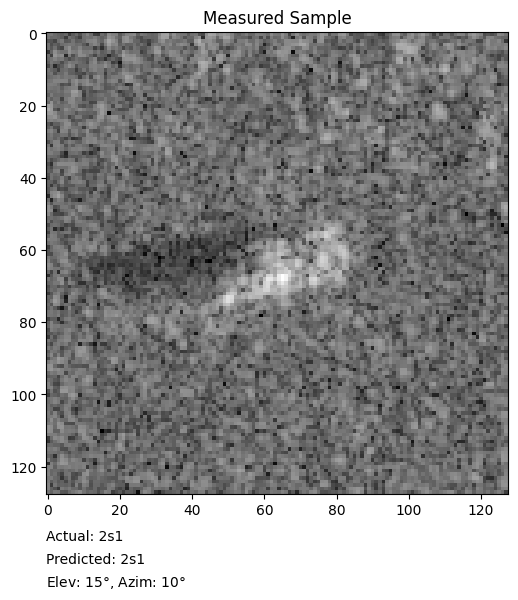

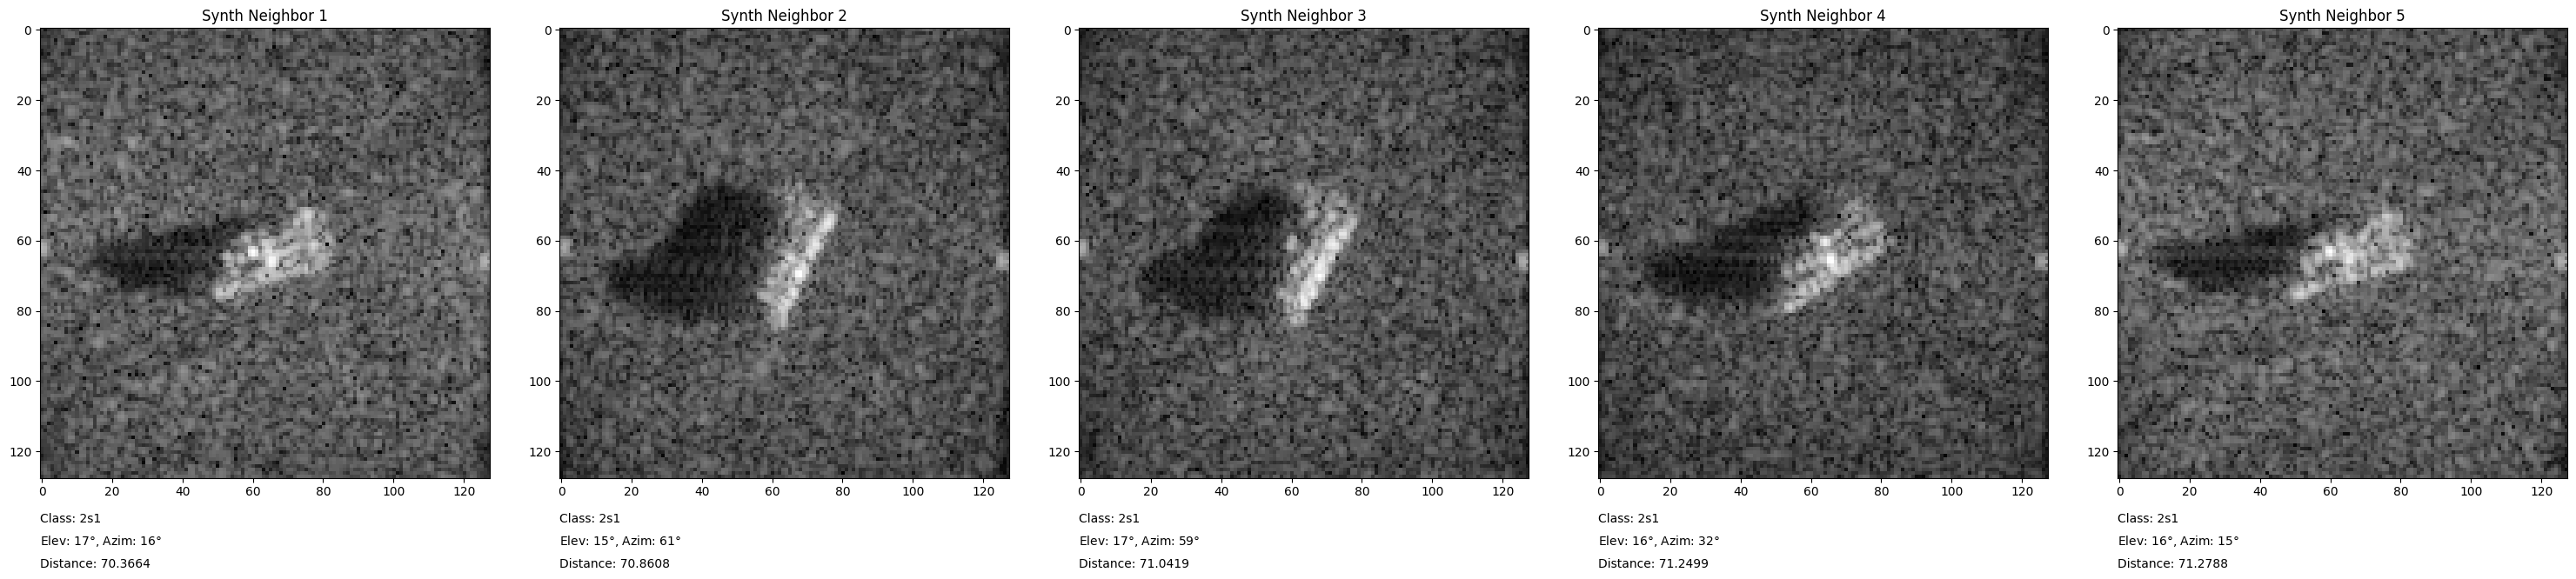

In [127]:
# measured sample visualization
meas_idx = 0
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(meas_ds[meas_idx][0][0], cmap = "gray")

meas_sample_path, meas_sample_class = meas_ds.samples[meas_idx]
elev_re = re.search(r'elevDeg_(\d+)', meas_sample_path)
azim_re = re.search(r'azCenter_(\d+)', meas_sample_path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

ax.set_title(f"Measured Sample")
ax.text(0, -0.1, f"Actual: {meas_ds.classes[meas_sample_class]}", transform=ax.transAxes)
ax.text(0, -0.15, f"Predicted: {meas_ds.classes[pred_class[meas_idx]]}", transform=ax.transAxes)
ax.text(0, -0.2, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
plt.show()

fig = plt.figure(figsize=(30, 6))
for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1)
    synth_idx = knn_idx_pred_5[i]
    ax.imshow(synth_ds[synth_idx][0][0], cmap = "gray")
    synth_sample_path, synth_sample_class = synth_ds.samples[synth_idx]
    elev_re = re.search(r'elevDeg_(\d+)', synth_sample_path)
    azim_re = re.search(r'azCenter_(\d+)', synth_sample_path)

    elev = int(elev_re.group(1))
    azim = int(azim_re.group(1))

    ax.set_title(f"Synth Neighbor {i+1}")
    ax.text(0, -0.1, f"Class: {synth_ds.classes[synth_sample_class]}", transform=ax.transAxes)
    ax.text(0, -0.15, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
    ax.text(0, -0.2, f"Distance: {knn_dist_pred_5[i]:.4f}", transform=ax.transAxes)
plt.tight_layout()
plt.show()

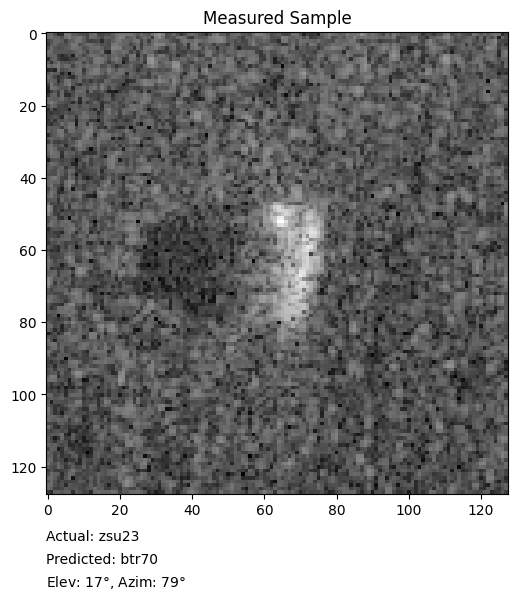

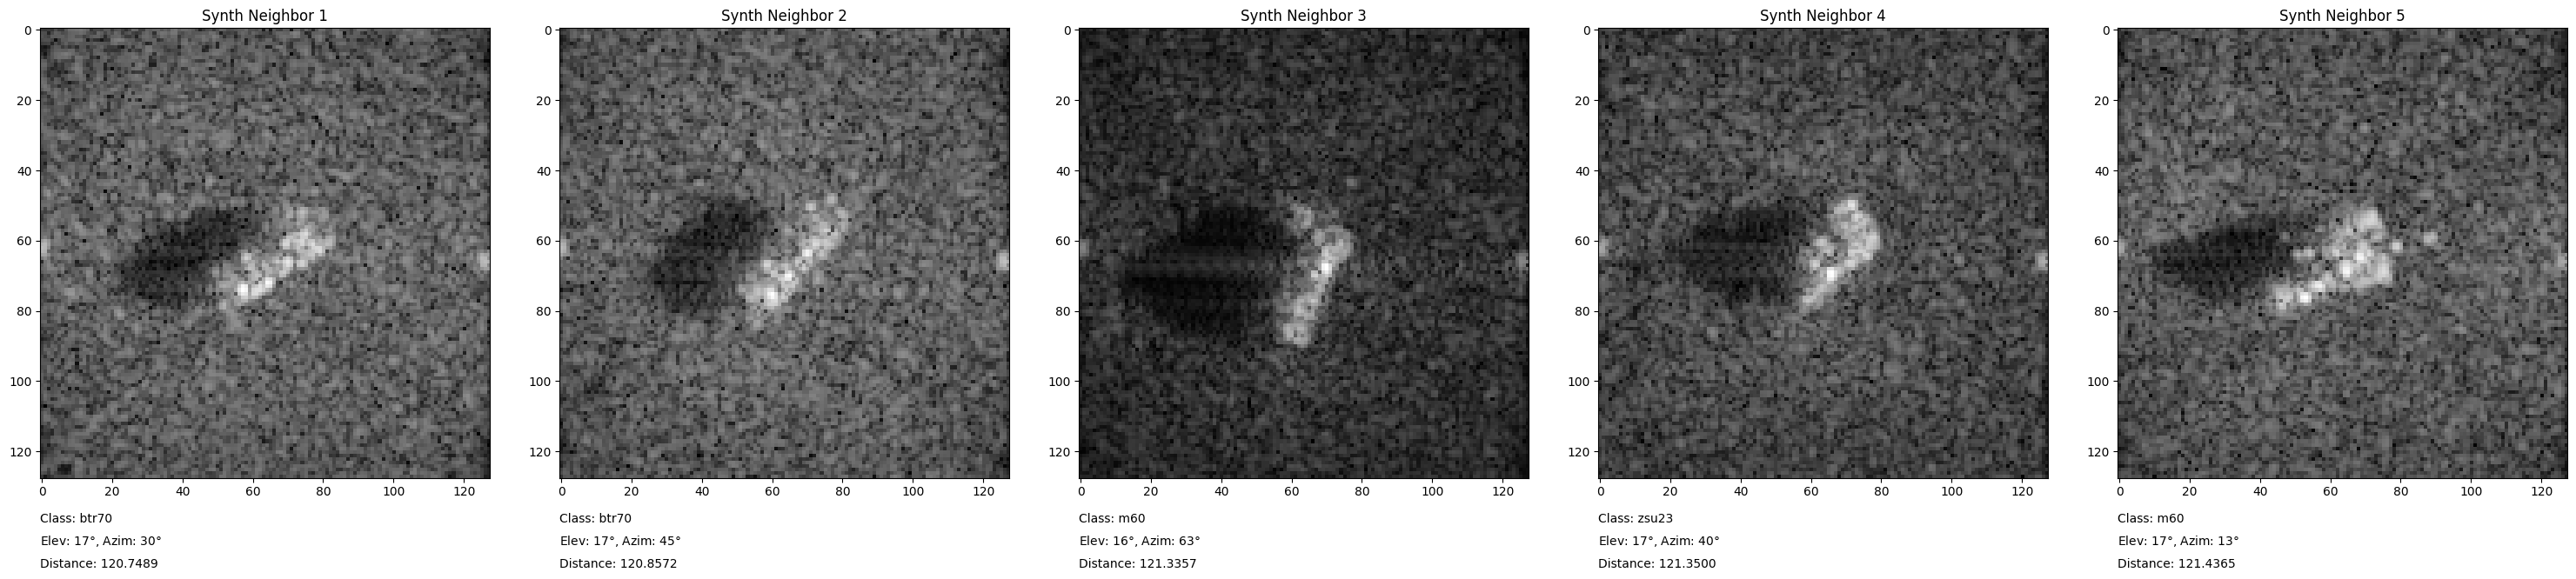

In [93]:
wrong_knn_idx, wrong_knn_dist =_k_nearest_neighbors(meas_features[-1, :], synth_features, synth_sigma_inv, k=5)
wrong_knn_idx, wrong_knn_dist

# measured sample visualization
meas_idx = -1
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(meas_ds[meas_idx][0][0], cmap = "gray")

meas_sample_path, meas_sample_class = meas_ds.samples[meas_idx]
elev_re = re.search(r'elevDeg_(\d+)', meas_sample_path)
azim_re = re.search(r'azCenter_(\d+)', meas_sample_path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

ax.set_title(f"Measured Sample")
ax.text(0, -0.1, f"Actual: {meas_ds.classes[meas_sample_class]}", transform=ax.transAxes)
ax.text(0, -0.15, f"Predicted: {meas_ds.classes[pred_class[meas_idx]]}", transform=ax.transAxes)
ax.text(0, -0.2, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
plt.show()

fig = plt.figure(figsize=(30, 6))
for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1)
    synth_idx = wrong_knn_idx[i]
    ax.imshow(synth_ds[synth_idx][0][0], cmap = "gray")
    synth_sample_path, synth_sample_class = synth_ds.samples[synth_idx]
    elev_re = re.search(r'elevDeg_(\d+)', synth_sample_path)
    azim_re = re.search(r'azCenter_(\d+)', synth_sample_path)

    elev = int(elev_re.group(1))
    azim = int(azim_re.group(1))

    ax.set_title(f"Synth Neighbor {i+1}")
    ax.text(0, -0.1, f"Class: {synth_ds.classes[synth_sample_class]}", transform=ax.transAxes)
    ax.text(0, -0.15, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
    ax.text(0, -0.2, f"Distance: {wrong_knn_dist[i]:.4f}", transform=ax.transAxes)
plt.tight_layout()
plt.show()

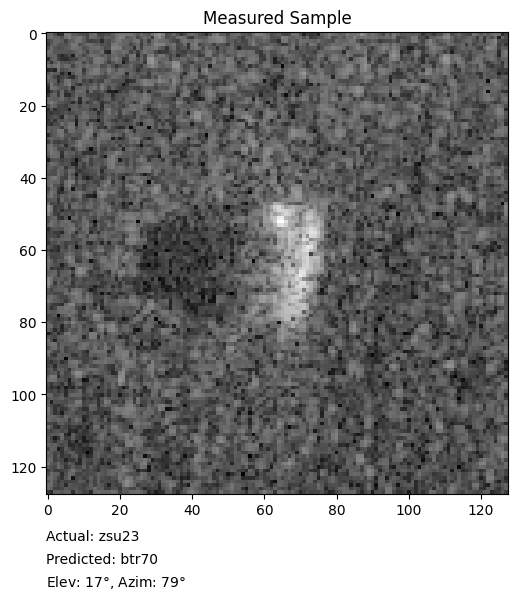

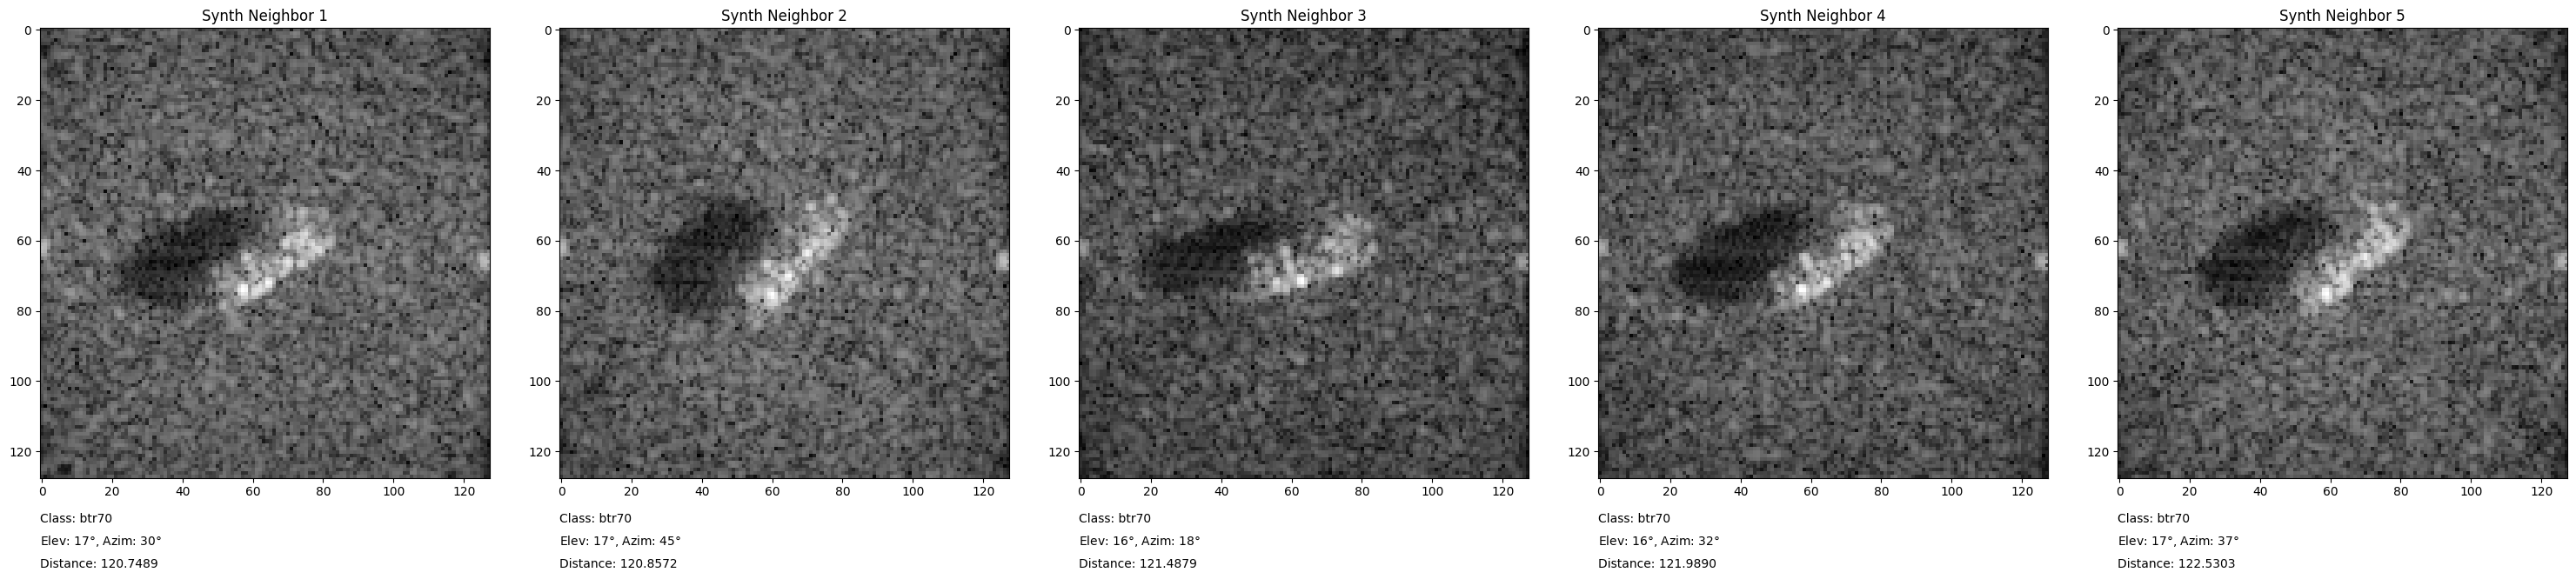

In [128]:
wrong_knn_idx, wrong_knn_dist = _k_nearest_neighbors_from_predicted_class(meas_features[-1, :], synth_features, synth_labels, synth_sigma_inv, predicted_class_idx = 2, k = 5)

# measured sample visualization
meas_idx = -1
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.imshow(meas_ds[meas_idx][0][0], cmap = "gray")

meas_sample_path, meas_sample_class = meas_ds.samples[meas_idx]
elev_re = re.search(r'elevDeg_(\d+)', meas_sample_path)
azim_re = re.search(r'azCenter_(\d+)', meas_sample_path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

ax.set_title(f"Measured Sample")
ax.text(0, -0.1, f"Actual: {meas_ds.classes[meas_sample_class]}", transform=ax.transAxes)
ax.text(0, -0.15, f"Predicted: {meas_ds.classes[pred_class[meas_idx]]}", transform=ax.transAxes)
ax.text(0, -0.2, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
plt.show()

fig = plt.figure(figsize=(30, 6))
for i in range(5):
    ax = fig.add_subplot(1, 5, i + 1)
    synth_idx = wrong_knn_idx[i]
    ax.imshow(synth_ds[synth_idx][0][0], cmap = "gray")
    synth_sample_path, synth_sample_class = synth_ds.samples[synth_idx]
    elev_re = re.search(r'elevDeg_(\d+)', synth_sample_path)
    azim_re = re.search(r'azCenter_(\d+)', synth_sample_path)

    elev = int(elev_re.group(1))
    azim = int(azim_re.group(1))

    ax.set_title(f"Synth Neighbor {i+1}")
    ax.text(0, -0.1, f"Class: {synth_ds.classes[synth_sample_class]}", transform=ax.transAxes)
    ax.text(0, -0.15, rf"Elev: ${int(elev)}\degree$, Azim: ${int(azim)}\degree$", transform=ax.transAxes)
    ax.text(0, -0.2, f"Distance: {wrong_knn_dist[i]:.4f}", transform=ax.transAxes)
plt.tight_layout()
plt.show()